<h1>Topic: T-test and Wilcox-test</h1>

Check if data was correctly imported, this should show the head of the data as a table.

In [1]:
data <- read.csv2("./200.txt")
head(data)

,mode,dist
,<chr>,<int>
1,car,13
2,car,19
3,car,8
4,public transport,14
5,car,18
6,public transport,24


Set varibales as described in task


In [2]:
alpha <- 0.005
expected <- 28

Make a boxplot to see if there are many outliers, if there are many outliers that might affect the t-test negatively.
The Wilcox test is not as affected by these outliers.

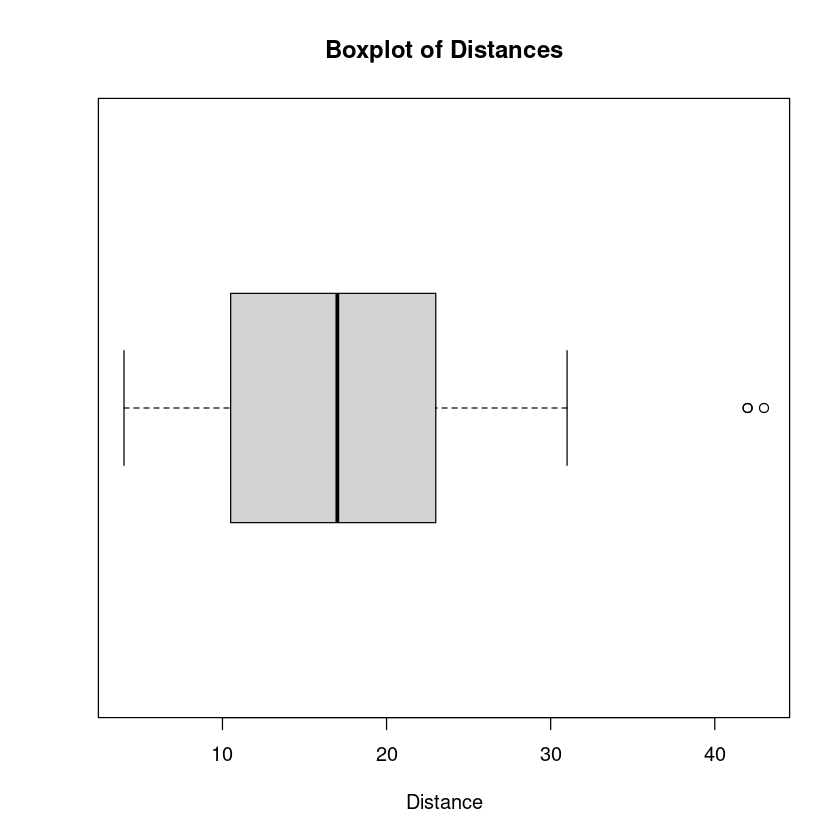

In [3]:
par(bg = "white")

boxplot(
    data$dist,
    main = "Boxplot of Distances",
    xlab = "Distance",
    horizontal = TRUE
)


We can see that there are some outliers, however it is not clear that these will skew the results heavily (if we had outliers at for example 8000 we can assume that it will skew the results heavily). <br>
We can create a dataset without outliers and compare medians and standard deviation to have a closer look.


In [4]:
outliers <- boxplot.stats(data$dist)$out
dist_no_outliers <- data$dist[!(data$dist %in% outliers)]


Check the mean and standard deviation of our samples.<br>


In [5]:
mean(data$dist)
sd(data$dist)

mean(dist_no_outliers)
sd(dist_no_outliers)

[1] 17.38182

[1] 8.994836

[1] 15.94231

[1] 6.849684

The resultsthat these values do not deviate much depending on whether or not we exclude outliers.<br>
This suggests that we can use the t-test. <br>
Furthermore the mean is much lower than the expected 28, however we cannot say that this didn't happen by chance and need to perform a t-test.

We use a t-test to check how likely it is that the mean of 17 happened by chance, and that we cannot discard our hypothesis.<br>
We use a two sided one as the mean being either above or below will cause us to discard our hypothesis.

In [6]:
t.test(
    data$dist,
    mu = expected,
    alternative = "two.sided",
    conf.level = 1- alpha
)


	One Sample t-test

data:  data$dist
t = -8.7546, df = 54, p-value = 6.088e-12
alternative hypothesis: true mean is not equal to 28
99.5 percent confidence interval:
 13.83181 20.93183
sample estimates:
mean of x 
 17.38182 


p value is much lower than 0.005 -> reject hypothesis.<br>
Or:<br>
The actual 99.5% confidence interval is from ~13.83 to ~20.93<br>
As 28 is not in the interval, we reject our hypothesis.

You can also use the wilcox test to test the hyptohesis.

In [7]:
wilcox.test(
    data$dist,
    mu = expected,
    conf.int = TRUE,
    conf.level = 1- alpha
)


	Wilcoxon signed rank test with continuity correction

data:  data$dist
V = 99.5, p-value = 3.111e-08
alternative hypothesis: true location is not equal to 28
99.5 percent confidence interval:
 13.49998 20.00001
sample estimates:
(pseudo)median 
      16.50007 


We can see that the confidence interval is smaller than in the t-test. <br>
This suggests that outliers did affect the t-test, however in both cases we still discard the null hypothesis.